# Linear Regression

## 0. Package Importing

In [6]:
from utils import *

## 1. Data Loading

In [7]:
advertising = pd.DataFrame(pd.read_csv("advertising.csv"))
advertising = advertising[['TV', 'Sales']]

X = advertising['TV'].to_numpy()
y = advertising['Sales'].to_numpy()

In [18]:
X.shape


(200,)

## 2. Data Preprocessing

In [9]:
X = (X-X.mean()+1)/np.std(X)

## 3. Data Plotting

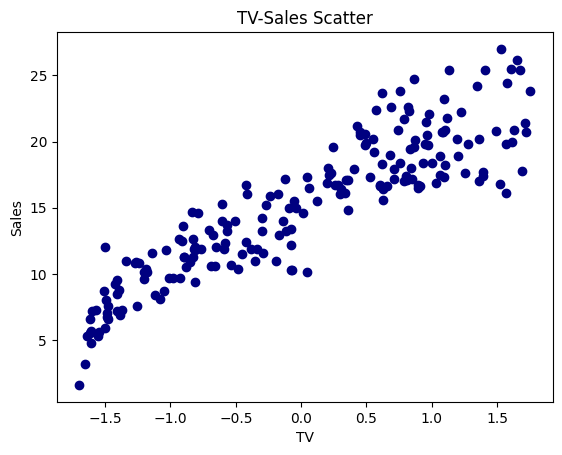

In [10]:
plt.scatter(X, y, c = 'navy')
plt.xlabel('TV')
plt.ylabel('Sales')
plt.title('TV-Sales Scatter')
plt.show()

## 4. Regression Line Plotting

W = 5, b = 5, Loss = 106.7278
W = 5, b = 10, Loss = 31.0066
W = 5, b = 15, Loss = 5.2855
W = 10, b = 5, Loss = 133.0554
W = 10, b = 10, Loss = 57.9181
W = 10, b = 15, Loss = 32.7808
W = 15, b = 5, Loss = 209.3899
W = 15, b = 10, Loss = 134.8364
W = 15, b = 15, Loss = 110.2829

Best combination:
W = 5, b = 15, Lowest Loss = 5.2855


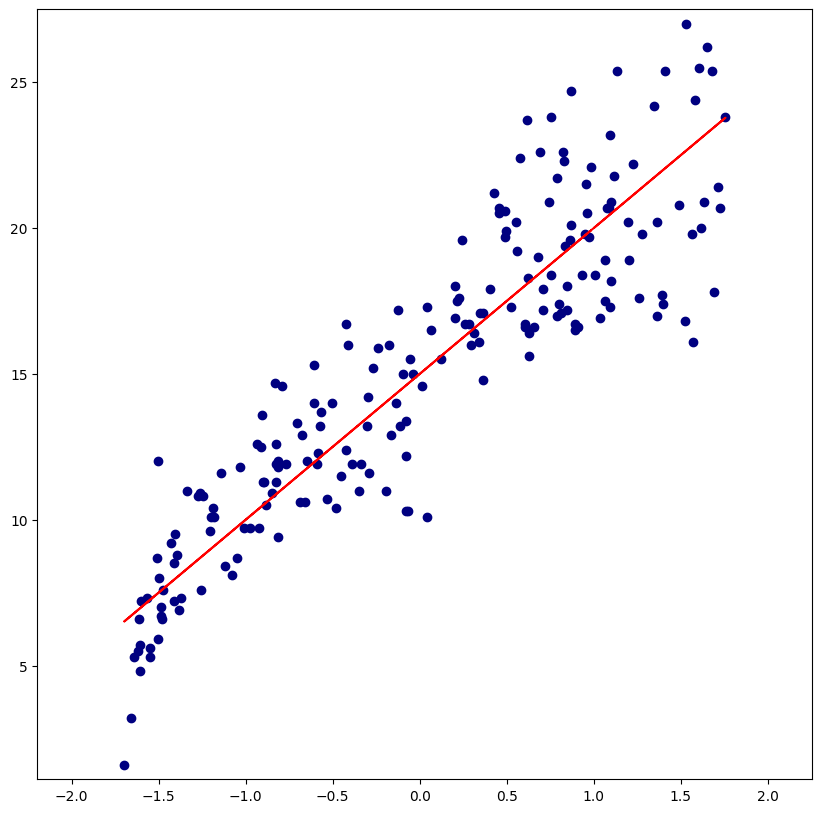

In [23]:
W = 5
b = 15
y_pred = W*X + b

fig = plt.figure(figsize = (10,10))

ax = fig.add_subplot(111)
data_fitted_visualizer(X, y, y_pred)


# make sure X and y are already defined
def compute_loss(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

W_list = [5, 10, 15]
b_list = [5, 10, 15]

best_loss = float('inf')
best_W = None
best_b = None

for W in W_list:
    for b in b_list:
        y_pred = W * X + b
        loss = compute_loss(y, y_pred)
        print(f"W = {W}, b = {b}, Loss = {loss:.4f}")
        if loss < best_loss:
            best_loss = loss
            best_W = W
            best_b = b

print("\nBest combination:")
print(f"W = {best_W}, b = {best_b}, Lowest Loss = {best_loss:.4f}")

## 5.1. Parameter Fitting: Gradient Descent

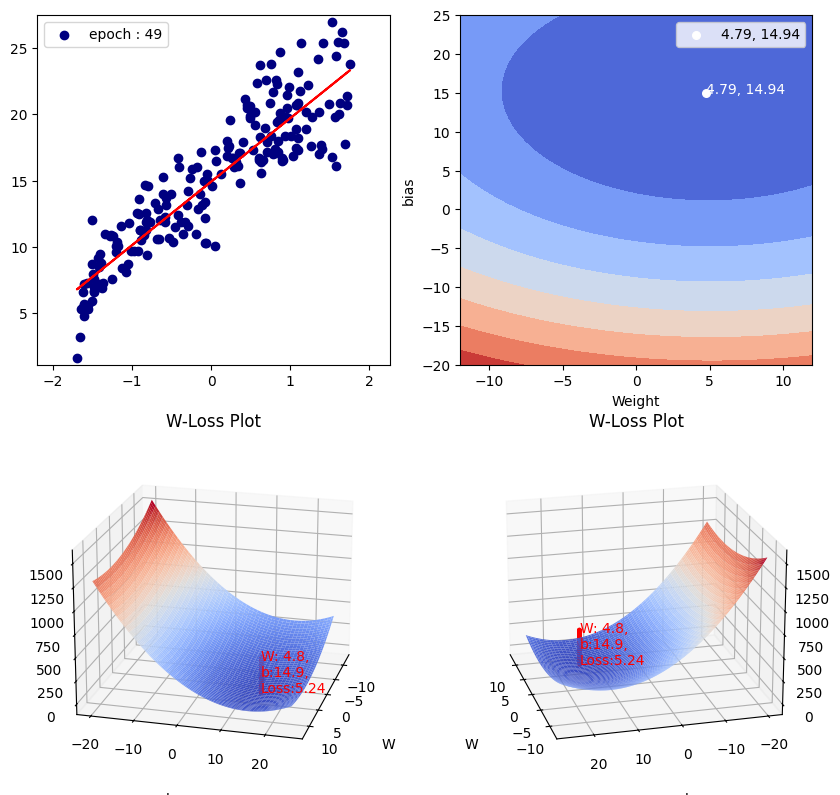

In [27]:
################# initialize hyperparams ######################

W = 10
b = -10
learning_rate = 0.1
epochs = 50
tol = 1e-3
time_sleep = 0.2

################################################################

W_mesh, b_mesh, loss_out = mesh_loss_out_generator(X,y, (-12,12), (-20,25), 100)

loss_list = []
W_list = []
b_list = []
for epoch in range(epochs):
    y_pred = W*X + b

    # MSE loss fucntion
    loss = ((y_pred - y)**2).mean()

    # compute gradient
    W_grad = ((y_pred - y)*X).mean()
    b_grad = (y_pred - y).mean()

    # parameter update
    W = W - learning_rate * W_grad
    b = b - learning_rate * b_grad

    # Plotting
    fig = plt.figure(figsize = (10,10))

    ax = fig.add_subplot(221)
    data_fitted_visualizer(X, y, y_pred, epoch)

    ax = fig.add_subplot(222)
    contour_2d(W, b, W_mesh, b_mesh, loss_out, ax, cmap_color=plt.cm.coolwarm, x_label = 'Weight', y_label = 'bias')

    ax = fig.add_subplot(223, projection='3d')
    loss_func_visualizer_3d(W, b, W_mesh, b_mesh, loss_out, X, y, ax, angle = (20,15))

    ax = fig.add_subplot(224, projection='3d')
    loss_func_visualizer_3d(W, b, W_mesh, b_mesh, loss_out, X, y, ax, angle = (20,165), clear =True)

    time.sleep(time_sleep)

    loss_list.append(loss)
    W_list.append(W)
    b_list.append(b)

    if loss < tol:
        break


In [13]:
for l, w, b in zip(loss_list, W_list, b_list):
    print(f"loss:{l:.4f}, W:{w:.4f}, b:{b:.4f}")

loss:141.1436, W:-0.4132, b:6.0142
loss:115.0702, W:0.1138, b:6.9263
loss:93.9984, W:0.5870, b:7.7466
loss:76.9687, W:1.0119, b:8.4843
loss:63.2057, W:1.3935, b:9.1478
loss:52.0827, W:1.7361, b:9.7444
loss:43.0934, W:2.0437, b:10.2810
loss:35.8284, W:2.3200, b:10.7635
loss:29.9569, W:2.5681, b:11.1975
loss:25.2117, W:2.7908, b:11.5878
loss:21.3767, W:2.9908, b:11.9388
loss:18.2773, W:3.1704, b:12.2545
loss:15.7724, W:3.3317, b:12.5384
loss:13.7480, W:3.4765, b:12.7937
loss:12.1119, W:3.6065, b:13.0233
loss:10.7896, W:3.7233, b:13.2299
loss:9.7209, W:3.8281, b:13.4156
loss:8.8572, W:3.9223, b:13.5826
loss:8.1592, W:4.0068, b:13.7328
loss:7.5950, W:4.0827, b:13.8679
loss:7.1391, W:4.1508, b:13.9894
loss:6.7706, W:4.2120, b:14.0987
loss:6.4728, W:4.2670, b:14.1969
loss:6.2321, W:4.3163, b:14.2853
loss:6.0375, W:4.3606, b:14.3648
loss:5.8803, W:4.4004, b:14.4363
loss:5.7532, W:4.4361, b:14.5005
loss:5.6505, W:4.4681, b:14.5584
loss:5.5675, W:4.4969, b:14.6104
loss:5.5005, W:4.5228, b:14.65

## 5.2. Parameter Fitting: Normal Equation

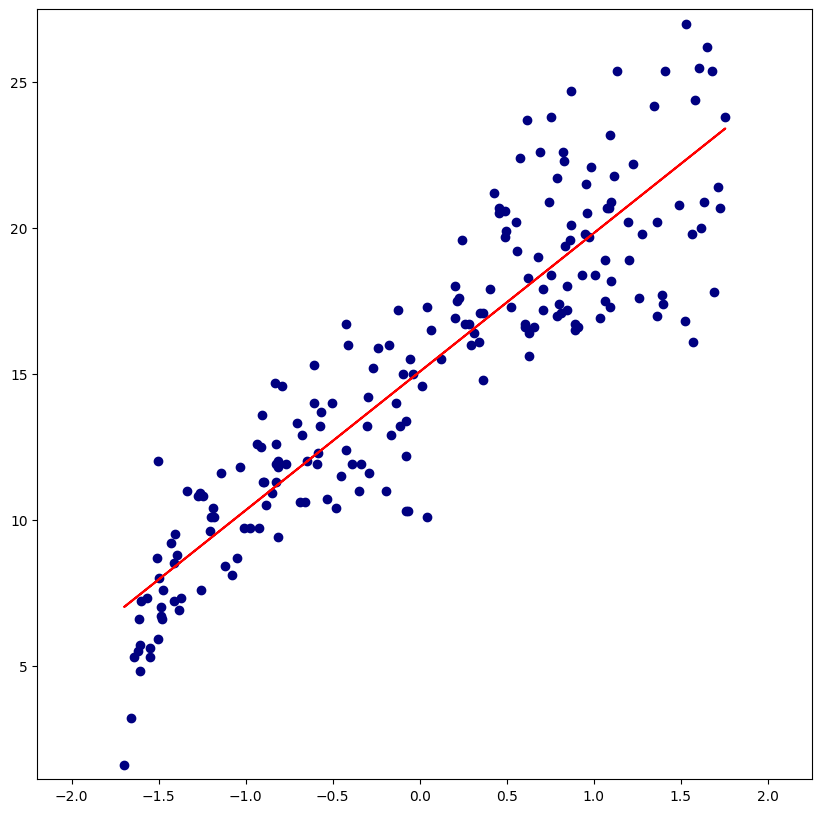

In [14]:
from numpy.linalg import inv

X_ = np.vstack([X, np.ones_like(X)]).T
W, b = np.dot(np.matmul(inv(np.matmul(X_.T, X_)), X_.T), y)
y_pred = W*X + b

fig = plt.figure(figsize = (10,10))

ax = fig.add_subplot(111)
data_fitted_visualizer(X, y, y_pred)